# Swin Transformer -- IQ-OTH/NCCD (224x224, 35 epochs, 100% fine-tuning, NO early stopping)
Same data pipeline as the EfficientNetB4 run: images pooled from the attached Kaggle mirror of the IQ-OTH/NCCD dataset (`Normal cases` / `Bengin cases` / `Malignant cases` folders, auto-detected under `/kaggle/input`), shuffled, and re-split stratified **60% train / 20% validation / 20% test** (`random_state=42`). 3 classes: normal, benign, malignant.

**Specifications for this run (same as EfficientNetB4, except no early stopping):**
- Image size: **224x224** (Swin-Base's native resolution)
- Batch size: **16**
- Epochs: **35, always runs the full 35 -- no early stopping**
- Optimizer: **Adam, learning_rate=5e-4**
- **100% fine-tuning** -- the entire Swin backbone is trainable from epoch 1
- **No data augmentation** and **no class weighting**

**Implementation note:** uses Hugging Face `transformers`' `TFSwinForImageClassification` (`microsoft/swin-base-patch4-window7-224`), wrapped in a small subclassed Keras model for the channel-layout difference. **Needs internet access enabled in the Kaggle notebook** to download pretrained weights.

**Note:** make sure the IQ-OTH/NCCD Kaggle dataset is attached to this notebook (Add Data) before running -- cell 0 will show it under `/kaggle/input` if it's attached correctly.

## 0. Explore /kaggle/input

In [1]:
import os

max_depth = 4
base_depth = "/kaggle/input".count(os.sep)
for dirpath, dirnames, filenames in os.walk("/kaggle/input"):
    depth = dirpath.count(os.sep) - base_depth
    if depth > max_depth:
        dirnames[:] = []
        continue
    indent = "  " * depth
    print(f"{indent}{os.path.basename(dirpath) or dirpath}/  [{len(filenames)} files]  {filenames[:2]}")

input/  [0 files]  []
  datasets/  [0 files]  []
    hamdallak/  [0 files]  []
      the-iqothnccd-lung-cancer-dataset/  [0 files]  []
        The IQ-OTHNCCD lung cancer dataset/  [1 files]  ['IQ-OTH_NCCD lung cancer dataset.txt']


## 1. Install + Imports
Pinned to `transformers==4.46.3` specifically -- Hugging Face deprecated and then fully removed TensorFlow support from `transformers` (merged ~May 2025), so any recent/latest install no longer has `TFSwinForImageClassification` at all (`pip install -U transformers` will break with an ImportError). 4.46.3 is a pre-deprecation release confirmed to still include the TF Swin classes.

**Also installs `tf-keras`** -- current TensorFlow defaults to Keras 3, but `transformers`' TF models (including `TFSwinForImageClassification`) were built against legacy Keras 2 and silently fail to build their weights under Keras 3 (symptom: `model.weights` comes back empty, `trainable_fraction` divides by zero in the FLOPs cell). Setting `TF_USE_LEGACY_KERAS=1` **before** `tensorflow` is imported tells TensorFlow to use the legacy `tf_keras` package instead of its bundled Keras 3.

**If you already ran this notebook once and hit the FLOPs `ZeroDivisionError` or a Swin-related build issue: restart the kernel before re-running from cell 1.** The env var only takes effect if it's set before TensorFlow is imported for the first time in the session -- it won't retroactively fix an already-running kernel.

In [2]:
!pip install -q "transformers==4.46.3" tf-keras

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 92.8 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 83.0 MB/s eta 0:00:00:00:01


In [3]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"  # must be set BEFORE tensorflow is imported

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from transformers import TFSwinForImageClassification

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

print("Keras version in use:", tf.keras.__version__ if hasattr(tf.keras, "__version__") else "unknown")

TARGET_CLASSES = ["normal", "benign", "malignant"]
CLASS_TO_IDX = {c: i for i, c in enumerate(TARGET_CLASSES)}
NUM_CLASSES = len(TARGET_CLASSES)

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 35
LEARNING_RATE = 5e-4
SWIN_CHECKPOINT = "microsoft/swin-base-patch4-window7-224"

Keras version in use: unknown


## 2. Locate the IQ-OTH/NCCD dataset + build a dataframe

In [4]:
def fuzzy_map_class(folder_name):
    n = folder_name.lower()
    if "normal" in n:
        return "normal"
    if "benign" in n or "bengin" in n:
        return "benign"
    if "malignant" in n:
        return "malignant"
    return None

records = []
found_dirs = []
for dirpath, dirnames, filenames in os.walk("/kaggle/input"):
    label = fuzzy_map_class(os.path.basename(dirpath))
    if label is None:
        continue
    image_files = [f for f in filenames if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))]
    if not image_files:
        continue
    found_dirs.append((dirpath, label, len(image_files)))
    for fname in image_files:
        records.append({"filepath": os.path.join(dirpath, fname), "label": label})

print("Matched folders:")
for d, l, n in found_dirs:
    print(f"  {d}  ->  {l}  ({n} images)")

full_pool = pd.DataFrame(records)
assert len(full_pool) > 0, "No images found -- make sure the IQ-OTH/NCCD dataset is attached under /kaggle/input"

print("\nPooled total:", len(full_pool))
print(full_pool["label"].value_counts())

Matched folders:
  /kaggle/input/datasets/hamdallak/the-iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset/Normal cases  ->  normal  (416 images)
  /kaggle/input/datasets/hamdallak/the-iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset/Bengin cases  ->  benign  (120 images)
  /kaggle/input/datasets/hamdallak/the-iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset/Malignant cases  ->  malignant  (561 images)

Pooled total: 1097
label
malignant    561
normal       416
benign       120
Name: count, dtype: int64


## 3. Shuffle + stratified 60/20/20 split

In [5]:
full_pool = full_pool.sample(frac=1.0, random_state=42).reset_index(drop=True)

train_df, temp_df = train_test_split(
    full_pool, train_size=0.60, stratify=full_pool["label"], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, train_size=0.50, stratify=temp_df["label"], random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train size:", len(train_df), " Val size:", len(val_df), " Test size:", len(test_df))
print("\nTrain class balance:\n", train_df["label"].value_counts())
print("\nVal class balance:\n", val_df["label"].value_counts())
print("\nTest class balance:\n", test_df["label"].value_counts())

Train size: 658  Val size: 219  Test size: 220

Train class balance:
 label
malignant    336
normal       250
benign        72
Name: count, dtype: int64

Val class balance:
 label
malignant    112
normal        83
benign        24
Name: count, dtype: int64

Test class balance:
 label
malignant    113
normal        83
benign        24
Name: count, dtype: int64


## 4. Data generators -- no augmentation, ImageNet mean/std normalization for Swin

In [6]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def swin_preprocess(img):
    img = img / 255.0
    img = (img - IMAGENET_MEAN) / IMAGENET_STD
    return img

datagen = ImageDataGenerator(preprocessing_function=swin_preprocess)

train_gen = datagen.flow_from_dataframe(
    train_df, x_col="filepath", y_col="label",
    target_size=IMG_SIZE, class_mode="categorical",
    classes=TARGET_CLASSES, batch_size=BATCH_SIZE, shuffle=True, seed=42
)
val_gen = datagen.flow_from_dataframe(
    val_df, x_col="filepath", y_col="label",
    target_size=IMG_SIZE, class_mode="categorical",
    classes=TARGET_CLASSES, batch_size=BATCH_SIZE, shuffle=False
)
test_gen = datagen.flow_from_dataframe(
    test_df, x_col="filepath", y_col="label",
    target_size=IMG_SIZE, class_mode="categorical",
    classes=TARGET_CLASSES, batch_size=BATCH_SIZE, shuffle=False
)
print("class_indices:", train_gen.class_indices)

Found 658 validated image filenames belonging to 3 classes.
Found 219 validated image filenames belonging to 3 classes.
Found 220 validated image filenames belonging to 3 classes.
class_indices: {'normal': 0, 'benign': 1, 'malignant': 2}


## 5. Model -- Swin Transformer (Base, 224), 100% trainable from the start

In [7]:
class SwinClassifier(tf.keras.Model):
    def __init__(self, num_classes, checkpoint=SWIN_CHECKPOINT):
        super().__init__()
        self.backbone = TFSwinForImageClassification.from_pretrained(
            checkpoint, num_labels=num_classes, ignore_mismatched_sizes=True
        )
        self.backbone.trainable = True  # 100% fine-tuning -- entire backbone trainable from epoch 1

    def call(self, inputs, training=False):
        x = tf.transpose(inputs, perm=[0, 3, 1, 2])  # NHWC -> NCHW (HF Swin expects channels-first)
        outputs = self.backbone(pixel_values=x, training=training)
        return outputs.logits

model = SwinClassifier(num_classes=NUM_CLASSES)
_ = model(tf.zeros((1, 224, 224, 3), dtype=tf.float32))  # dummy forward pass -- forces all sub-layer weights to actually build
model.summary()

model.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    optimizer=Adam(learning_rate=LEARNING_RATE),
    metrics=["accuracy"]
)

I0000 00:00:1789931117.331195      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789931117.334114      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/352M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFSwinForImageClassification: ['classifier.bias', 'classifier.weight']
- This IS expected if you are initializing TFSwinForImageClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFSwinForImageClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFSwinForImageClassification were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFSwinForImageClassification for predictions without further training.
Some weights of TFSwinForImageClassification were not initialized from the model checkpoint are newly init

Model: "swin_classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 tf_swin_for_image_classifi  multiple                  86803923  
 cation (TFSwinForImageClas                                      
 sification)                                                     
                                                                 
Total params: 86803923 (331.13 MB)
Trainable params: 86746299 (330.91 MB)
Non-trainable params: 57624 (225.09 KB)
_________________________________________________________________


## 6. FLOPs -- cost of fine-tuning (image-wise and batch-wise)

In [8]:
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2_as_graph

def get_flops(keras_model, input_shape, batch_size=1):
    """Forward-pass FLOPs for `keras_model` at the given batch size, via TF's graph profiler."""
    full_shape = [batch_size] + list(input_shape)
    concrete_func = tf.function(lambda x: keras_model(x)).get_concrete_function(
        tf.TensorSpec(full_shape, tf.float32)
    )
    frozen_func, graph_def = convert_variables_to_constants_v2_as_graph(concrete_func)
    with tf.Graph().as_default() as graph:
        tf.graph_util.import_graph_def(graph_def, name="")
        run_meta = tf.compat.v1.RunMetadata()
        opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()
        flops = tf.compat.v1.profiler.profile(graph=graph, run_meta=run_meta, cmd="op", options=opts)
    return flops.total_float_ops

trainable_param_count = sum(int(tf.size(w)) for w in model.trainable_weights)
total_param_count = sum(int(tf.size(w)) for w in model.weights)
trainable_fraction = trainable_param_count / total_param_count

BACKWARD_MULTIPLIER = 2 * trainable_fraction
TOTAL_MULTIPLIER = 1 + BACKWARD_MULTIPLIER

print(f"Trainable params: {trainable_param_count:,} / {total_param_count:,}  (trainable_fraction={trainable_fraction:.4f})")
print(f"Derived training FLOPs multiplier: {TOTAL_MULTIPLIER:.4f}x forward\n")

flops_per_image_fwd = get_flops(model, input_shape=(224, 224, 3), batch_size=1)
flops_per_batch_fwd = get_flops(model, input_shape=(224, 224, 3), batch_size=BATCH_SIZE)

flops_per_image_bwd = flops_per_image_fwd * BACKWARD_MULTIPLIER
flops_per_batch_bwd = flops_per_batch_fwd * BACKWARD_MULTIPLIER

flops_per_image_total = flops_per_image_fwd * TOTAL_MULTIPLIER
flops_per_batch_total = flops_per_batch_fwd * TOTAL_MULTIPLIER

steps_per_epoch = len(train_df) // BATCH_SIZE
flops_per_epoch_total = flops_per_batch_total * steps_per_epoch
flops_full_run_total = flops_per_epoch_total * EPOCHS  # exact -- no early stopping

print("=== FORWARD ===")
print(f"Per image:  {flops_per_image_fwd:,}  (~{flops_per_image_fwd/1e9:.3f} GFLOPs)")
print(f"Per batch (batch_size={BATCH_SIZE}):  {flops_per_batch_fwd:,}  (~{flops_per_batch_fwd/1e9:.3f} GFLOPs)")

print("\n=== BACKWARD ===")
print(f"Per image:  {flops_per_image_bwd:,.0f}  (~{flops_per_image_bwd/1e9:.3f} GFLOPs)")
print(f"Per batch (batch_size={BATCH_SIZE}):  {flops_per_batch_bwd:,.0f}  (~{flops_per_batch_bwd/1e9:.3f} GFLOPs)")

print("\n=== TOTAL (forward + backward) ===")
print(f"Per image:  {flops_per_image_total:,.0f}  (~{flops_per_image_total/1e9:.3f} GFLOPs)")
print(f"Per batch (batch_size={BATCH_SIZE}):  {flops_per_batch_total:,.0f}  (~{flops_per_batch_total/1e9:.3f} GFLOPs)")
print(f"\nSteps per epoch: {steps_per_epoch}  (train set size {len(train_df)} / batch size {BATCH_SIZE})")
print(f"Per epoch:  {flops_per_epoch_total:,.0f}  (~{flops_per_epoch_total/1e12:.3f} TFLOPs)")
print(f"Full {EPOCHS}-epoch run (exact -- no early stopping):  {flops_full_run_total:,.0f}  (~{flops_full_run_total/1e15:.3f} PFLOPs)")

Trainable params: 86,746,299 / 86,803,923  (trainable_fraction=0.9993)
Derived training FLOPs multiplier: 2.9987x forward



I0000 00:00:1789931149.205379      58 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1789931149.205595      58 single_machine.cc:376] Starting new session
I0000 00:00:1789931149.220492      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789931149.222092      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.

=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
op: The nodes are operation ker

I0000 00:00:1789931206.574725      58 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1789931206.574973      58 single_machine.cc:376] Starting new session
I0000 00:00:1789931206.590059      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789931206.591669      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
op: The nodes are operation kernel type, such as MatMul, Conv2D. Graph nodes belonging to the same type are aggregated together.
flops: Number of float operations. Note: Please read the implementation for th

## 7. Callbacks -- NO early stopping

In [9]:
callbacks = [
    ModelCheckpoint(
        "best_swin_iqothnccd_224.weights.h5",
        monitor="val_accuracy",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    ),
]

## 8. Fine-tune (100% -- entire backbone trainable, full 35 epochs, no early stopping)

In [10]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/35


I0000 00:00:1789931346.862893     139 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


42/42 [==============================] - ETA: 0s - loss: 1.1324 - accuracy: 0.4878
Epoch 1: val_accuracy improved from -inf to 0.63470, saving model to best_swin_iqothnccd_224.weights.h5
42/42 [==============================] - 211s 2s/step - loss: 1.1324 - accuracy: 0.4878 - val_loss: 0.8312 - val_accuracy: 0.6347
Epoch 2/35


/usr/local/lib/python3.12/dist-packages/transformers/generation/tf_utils.py:465: UserWarning: `seed_generator` is deprecated and will be removed in a future version.
  warnings.warn("`seed_generator` is deprecated and will be removed in a future version.", UserWarning)


42/42 [==============================] - ETA: 0s - loss: 1.0207 - accuracy: 0.5334
Epoch 2: val_accuracy did not improve from 0.63470
42/42 [==============================] - 39s 924ms/step - loss: 1.0207 - accuracy: 0.5334 - val_loss: 1.1423 - val_accuracy: 0.5114
Epoch 3/35
42/42 [==============================] - ETA: 0s - loss: 1.0433 - accuracy: 0.4909
Epoch 3: val_accuracy did not improve from 0.63470
42/42 [==============================] - 37s 873ms/step - loss: 1.0433 - accuracy: 0.4909 - val_loss: 0.9747 - val_accuracy: 0.5114
Epoch 4/35
42/42 [==============================] - ETA: 0s - loss: 0.9961 - accuracy: 0.4468
Epoch 4: val_accuracy did not improve from 0.63470
42/42 [==============================] - 37s 892ms/step - loss: 0.9961 - accuracy: 0.4468 - val_loss: 0.9582 - val_accuracy: 0.5114
Epoch 5/35
42/42 [==============================] - ETA: 0s - loss: 1.0190 - accuracy: 0.4498
Epoch 5: val_accuracy did not improve from 0.63470
42/42 [============================

## 9. Plot train/val loss + accuracy

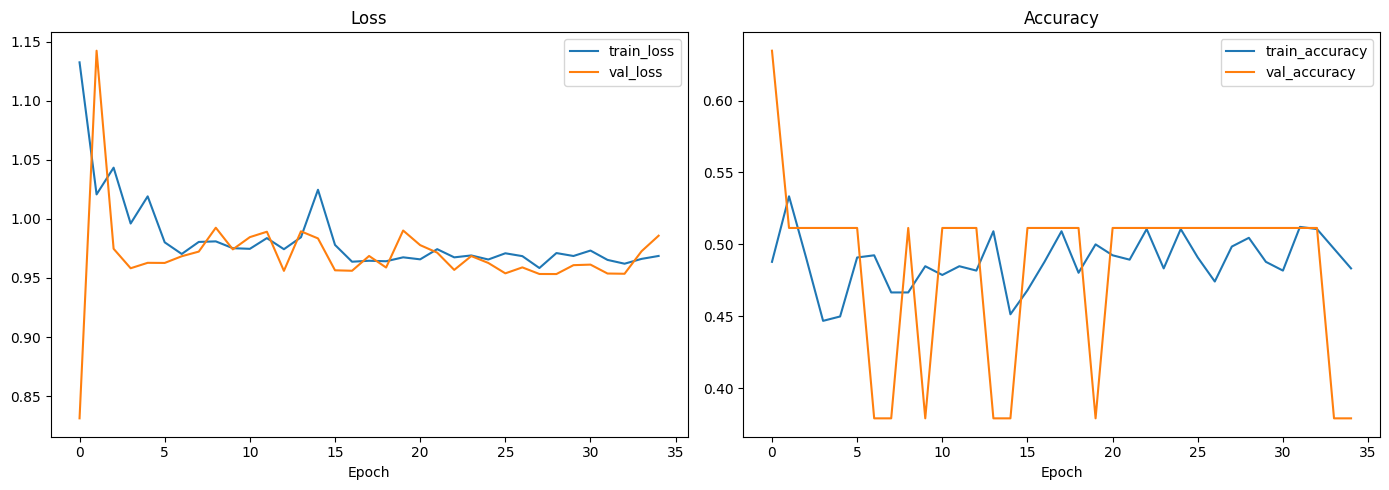

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["loss"], label="train_loss")
axes[0].plot(history.history["val_loss"], label="val_loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train_accuracy")
axes[1].plot(history.history["val_accuracy"], label="val_accuracy")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig("/kaggle/working/training_curves_swin_iqothnccd_224.png", dpi=150)
plt.show()

## 10. Final evaluation on TEST set

14/14 [==============================] - 4s 292ms/step - loss: 0.8075 - accuracy: 0.6273
Test loss: 0.8075  Test accuracy: 0.6273

Classification Report:
              precision    recall  f1-score   support

      normal     0.8929    0.3012    0.4505        83
      benign     0.0000    0.0000    0.0000        24
   malignant     0.5885    1.0000    0.7410       113

    accuracy                         0.6273       220
   macro avg     0.4938    0.4337    0.3971       220
weighted avg     0.6391    0.6273    0.5505       220

Test macro F1: 0.3971

Prediction distribution:
malignant    192
normal        28
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


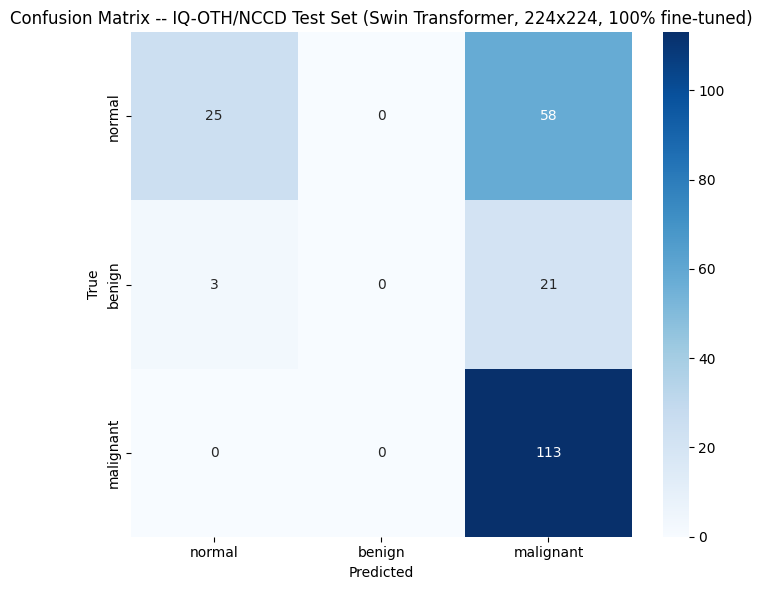


Swin Transformer (IQ-OTH/NCCD, 224x224) test accuracy: 62.73%


In [12]:
model.load_weights("best_swin_iqothnccd_224.weights.h5")

test_gen.reset()
test_loss, test_acc = model.evaluate(test_gen, verbose=1)
print(f"Test loss: {test_loss:.4f}  Test accuracy: {test_acc:.4f}")

test_gen.reset()
y_pred_logits = model.predict(test_gen, verbose=0)
y_pred_idx = np.argmax(y_pred_logits, axis=1)
y_true_idx = test_gen.classes

print("\nClassification Report:")
print(classification_report(y_true_idx, y_pred_idx, target_names=TARGET_CLASSES, digits=4))

test_macro_f1 = f1_score(y_true_idx, y_pred_idx, average="macro")
print(f"Test macro F1: {test_macro_f1:.4f}")

print("\nPrediction distribution:")
print(pd.Series(y_pred_idx).map({i: c for i, c in enumerate(TARGET_CLASSES)}).value_counts())

cm = confusion_matrix(y_true_idx, y_pred_idx)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=TARGET_CLASSES, yticklabels=TARGET_CLASSES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix -- IQ-OTH/NCCD Test Set (Swin Transformer, 224x224, 100% fine-tuned)")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix_swin_iqothnccd_224.png", dpi=150)
plt.show()

print(f"\nSwin Transformer (IQ-OTH/NCCD, 224x224) test accuracy: {test_acc*100:.2f}%")